In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from sympy.abc import alpha
from sympy.stats.sampling.sample_scipy import scipy
from scipy.optimize import differential_evolution as de
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import plotly.io as pio
pio.renderers.default = "notebook"

device = torch.device('cpu')

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Casting complex values to real discards the imaginary part")

In [2]:
from add_roughness import *

def plot_density_profile_1(matr):
    matrix = matr.clone()
    depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
    U = (1.e-0) * matrix[:, 1].real

    x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
    y_fill = torch.repeat_interleave(U, 2)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x_fill.detach().cpu().numpy(),
        y=y_fill.detach().cpu().numpy(),
        mode="lines",
        line=dict(color="darkgreen"),
        fill="tozeroy"
    ))

    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

plot_density_profile_1(transform_array(matr, rough_res))

In [3]:
import plotly.graph_objects as go

q = (torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/2.4)
theta = torch.tensor(np.deg2rad(data[:, 0]))

r_mod, r_mod_conv, mod_score = reflectometry(q, matr, initial_sigma1, initial_sigma2, I0, Ibkg, alpha2)

#exp_score = chain(torch.tensor(r0.real))
exp_score = torch.zeros_like(r_mod, dtype=torch.float64)


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()*1e-10,
    y=r0.real,
    mode='lines',
    line=dict(color='purple', width=2, dash='solid'),
    name='эксперимент'
))

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()[0:len(r_mod.tolist())]*1e-10,
    y=(I0*r_mod_conv).real.tolist(),
    mode='lines',
    line=dict(color='blue', width=2, dash='solid'),
    name='расчёт'
))

fig.update_layout(
    yaxis_type="log",
    xaxis_title='q, Å',
    yaxis_title='I',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.add_trace(go.Scatter(
    x=q[exp_score>0.001].cpu().detach().numpy()[0:len(r_mod[exp_score>0.001].tolist())]*1e-10,
    y=exp_score[exp_score>0.001].tolist(),
    mode='markers',
    line=dict(color='red', width=2, dash='solid'),
    name='нейро эксп'
))

fig.add_trace(go.Scatter(
    x=q[mod_score>0.001].cpu().detach().numpy()[0:len(r_mod[mod_score>0.001].tolist())]*1e-10,
    y=mod_score[mod_score>0.001].tolist(),
    mode='markers',
    line=dict(color='cyan', width=2, dash='solid'),
    name='нейро расчет'
))

score3 = torch.abs(mod_score-exp_score)
fig.add_trace(go.Scatter(
    x=q[score3>0.0001].cpu().detach().numpy()[0:len(r_mod[score3>0.0001].tolist())]*1e-10,
    y=score3[score3>0.0001].tolist(),
    mode='markers',
    line=dict(color='orange', width=2, dash='solid'),
    name='нейро невязка'
))

fig.show()

r = torch.tensor(r0/I0.cpu().detach().numpy())

In [4]:
sum(torch.pow(mod_score-exp_score,2))

tensor(0., dtype=torch.float64)

In [5]:
q.shape

torch.Size([185])

In [6]:
from optimizer import *
from objective_function import *
loss_function = Comparator(q, r)

In [7]:
from variables import *
x_d = initial_d.reshape(-1, 5)[:, 0:2].flatten()

In [8]:
objective_function1 = loss_function.compare
loss1 = objective_function1(matr, sigma1, sigma2, I0, Ibkg, alpha2, ref_type='model')

loss1

tensor(10.5288, dtype=torch.float64, grad_fn=<AddBackward0>)

Optimizing: 100%|████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 89.95it/s, lr=3.86e-02]


Stage 1: Learning Rate=0.02, Iterations=100, relative_loss=0.9472980603712317


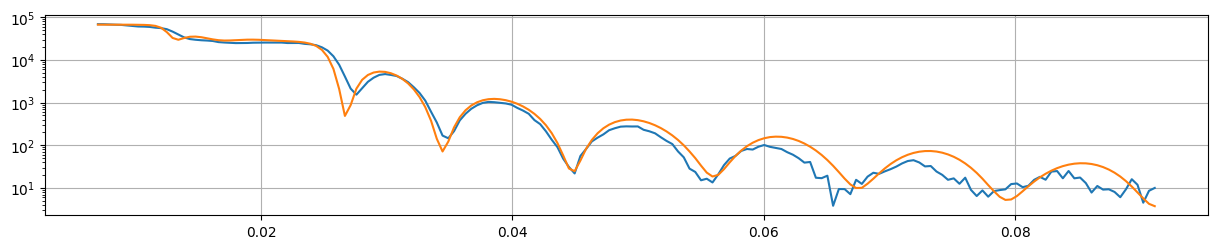

Optimizing: 100%|████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 89.55it/s, lr=2.21e-02]


Stage 2: Learning Rate=0.012, Iterations=200, relative_loss=0.8904061899305556


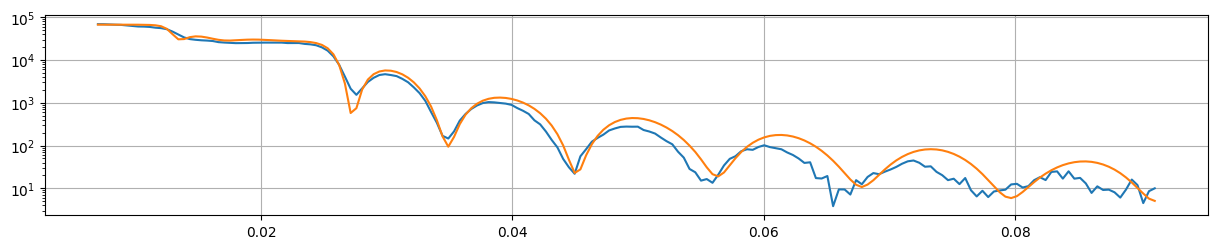

Optimizing: 100%|████████████████████████████████████████████████████████| 300/300 [00:03<00:00, 89.91it/s, lr=1.76e-02]


Stage 3: Learning Rate=0.01, Iterations=300, relative_loss=1.0039077218999939


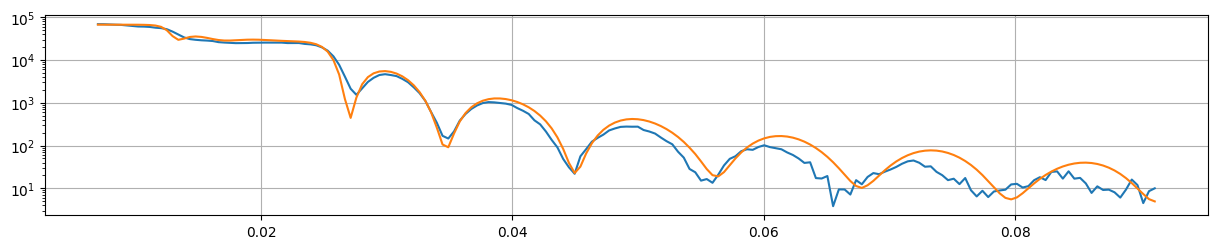

Optimizing: 100%|██████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 87.69it/s, lr=1.96e-02]


Stage DE 1: Learning Rate=0.01, Iterations=50.0, relative_loss=0.87716923809189, sigma1= 0.05988439945712555, sigma2= 0.010558716710147135


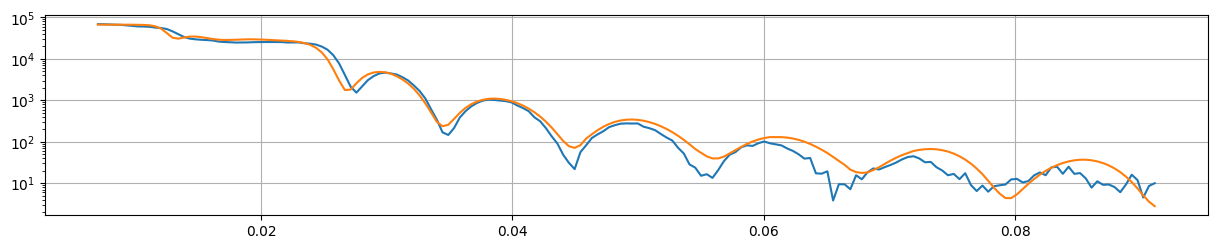

Optimizing: 100%|██████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 87.83it/s, lr=1.96e-02]


Stage DE 2: Learning Rate=0.01, Iterations=50.0, relative_loss=0.6601708449525779, sigma1= 0.05897546986519217, sigma2= 0.034247525965850366


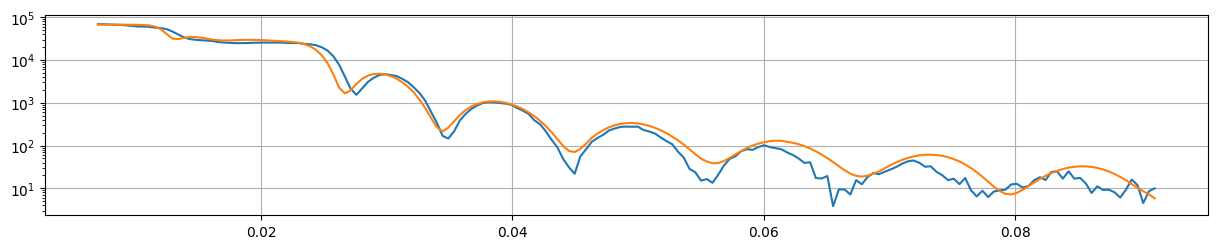

In [21]:
loss_classes = [
    varbounds(all_bounds, loss_function.compare, 0.4, matr, sigma1, sigma2, I0, Ibkg, alpha2, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_08, 0.4, matr, sigma1, sigma2, I0, Ibkg, alpha2, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_05, 0.2, matr, sigma1, sigma2, I0, Ibkg, alpha2, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_025, 0.1, matr, sigma1, sigma2, I0, Ibkg, alpha2, ref_type='model')
]

learning_rates = [0.02, 0.012, 0.01, 0.01]
iterations = [100, 200, 300, 200]
#betas=(0.9655, 0.99)

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, ans_sigma1, ans_sigma2, ans_alpha2, loss, rel_losses = pie_optimizer(q, r, (0.36, 0.996),    0.991,
 0.004, initial_d, initial_r_rho, initial_i_rho, I0, Ibkg, alpha2, initial_sigma1, initial_sigma2,
    learning_rates,
    iterations,
    loss_classes
)

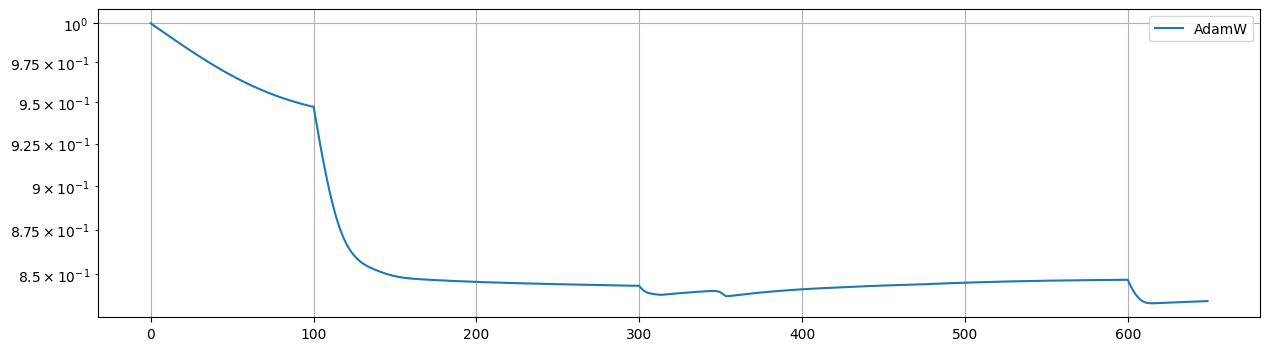

In [22]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [23]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,
                       torch.tensor([0, 5, 1, 2, 3, 4])]
r_mod, r_mod_conv, score= reflectometry(q, torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), ans_sigma1, ans_sigma2, I0, Ibkg, ans_alpha2)

#score2 = chain(torch.tensor(r0))
score2 = torch.zeros_like(r_mod, dtype=torch.float64)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()*1e-10,
    y=r0.real,
    mode='lines',
    line=dict(color='purple', width=2, dash='solid'),
    name='эксперимент'
))

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-10,
    y=(I0*r_mod_conv).real.tolist(),
    mode='lines',
    line=dict(color='blue', width=2, dash='solid'),
    name='расчёт'
))

fig.add_trace(go.Scatter(
    x=q[score2>0.001].cpu().detach().numpy()[0:len(r_mod[score2>0.001].tolist())]*1e-10,
    y=score2[score2>0.001].tolist(),
    mode='markers',
    line=dict(color='red', width=2, dash='solid'),
    name='нейро эксп'
))

fig.add_trace(go.Scatter(
    x=q[score>0.001].cpu().detach().numpy()[0:len(r_mod[score>0.001].tolist())]*1e-10,
    y=score[score>0.001].tolist(),
    mode='markers',
    line=dict(color='cyan', width=2, dash='solid'),
    name='нейро расчет'
))

score3 = torch.abs(score-score2)
fig.add_trace(go.Scatter(
    x=q[score3>0.001].cpu().detach().numpy()[0:len(r_mod[score3>0.001].tolist())]*1e-10,
    y=score3[score3>0.001].tolist(),
    mode='markers',
    line=dict(color='orange', width=2, dash='solid'),
    name='нейро невязка'
))


fig.update_layout(
    yaxis_type="log",
    xaxis_title='q, Å',
    yaxis_title='I',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

In [24]:
sum(torch.pow(score2-score,2))

tensor(0., dtype=torch.float64)

In [25]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,torch.tensor([0, 5, 1, 2,3,4])]
fig = plot_density_profile(transform_array(torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), rough_res))
fig.show()

In [26]:
torch.cat((combined_x_for_print.real[0,:], combined_x_for_print.real[1,[2, 3, 4,5]]), dim=0).detach().numpy()

array([4.8851913e+02, 1.0873967e+01, 6.0000000e+00, 5.5806464e-01,
       8.2200235e-01, 1.0000000e+00, 1.1960393e+01, 0.0000000e+00,
       1.0000000e-01, 2.3635331e-01], dtype=float32)

In [35]:
np_bounds = np.array([
    [350.0, 650.0], [8.0, 14.0], [1.0, 100.0], [0.0, 1.0], [0.0, 1.0], [0.0, 1.0],
    [1.0, 90.0], [0.0, 1.0], [0.0, 1.0], [0.0, 1.0]
])

var_vector = torch.cat((combined_x_for_print.real[0,:], combined_x_for_print.real[1,[2, 3, 4,5]]), dim=0).detach().numpy()

n_walkers = 48

sc = 0.04
sc_add = 0.0001

position = np.transpose(np.repeat(var_vector.reshape(-1, 1), n_walkers, axis = 1))

position+=position*(sc*np.random.rand(n_walkers, var_vector.shape[0])-sc/2)+(sc_add*np.random.rand(n_walkers, var_vector.shape[0])-sc_add/2)

vv = torch.tensor(var_vector)

In [36]:
torch.cat((matr[0, :], torch.tensor(var_vector[:6]), torch.cat((matr[2, :2], torch.tensor(var_vector[6:])), dim=0)), dim=0).reshape(-1, 6)

tensor([[1.0000e+02+0.j, 0.0000e+00+0.j, 0.0000e+00+0.j, 0.0000e+00+0.j, 0.0000e+00+0.j,
         0.0000e+00+0.j],
        [4.8852e+02+0.j, 1.0874e+01+0.j, 6.0000e+00+0.j, 5.5806e-01+0.j, 8.2200e-01+0.j,
         1.0000e+00+0.j],
        [1.0000e+02+0.j, 2.0740e+00+0.j, 1.1960e+01+0.j, 0.0000e+00+0.j, 1.0000e-01+0.j,
         2.3635e-01+0.j]], grad_fn=<ViewBackward0>)

In [37]:
ans_d.reshape(-1,5)[0, :]

tensor([488.5191,   6.0000,   0.5581,   0.8220,   1.0000])

In [38]:
var_vector

array([4.8851913e+02, 1.0873967e+01, 6.0000000e+00, 5.5806464e-01,
       8.2200235e-01, 1.0000000e+00, 1.1960393e+01, 0.0000000e+00,
       1.0000000e-01, 2.3635331e-01], dtype=float32)

In [39]:
from calculating_dynamic_resolution import resolution_function_smooth_step
sigmas = []
for q_i in q:
    sigmas.append(resolution_function_smooth_step(q[-1], q_i, sigma1, sigma2, gap).cpu().detach().numpy())
sigmas = np.array(sigmas)

def log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas=None):
    var_vector = torch.tensor(theta)
    q = q.cpu().detach().numpy()
    r_exp = r_exp.cpu().detach().numpy()

    new_matr = torch.cat((matr[0, :], var_vector[:6], torch.cat((matr[2, :2], var_vector[6:]), dim=0)), dim=0).reshape(-1, 6)

    _, r_model, score_model  = reflectometry(q, new_matr, sigma1, sigma2, I0, Ibkg, ans_alpha2)
    #score_exper = chain(torch.tensor(r_exp)).detach().numpy()
    #score_model = score_model.detach().numpy()
    if isinstance(r_model, torch.Tensor):
         r_model = r_model.real.cpu().detach().numpy()

    r_min = np.minimum(r_exp, r_model)
    #print(np.sum(((r_exp - r_model)/r_min)**2), np.sum(np.pow(score_model-score_exper,2)))

    return -0.5 * (np.sum(((r_exp - r_model)/np.pow(r_min, 0.75))**2))
    #- 10*np.sum(np.pow(score_model-score_exper,2))


def log_prior(theta):
    summa = 0

    for o, x in enumerate(theta):
        if (np_bounds[o,0]> x or x > np_bounds[o,1]):
            summa+=1

    if summa>0:
        return -np.inf
    return 0



def log_probability(theta, I0, Ibkg, q, r_exp, sigmas=None):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas)

In [40]:
import emcee

nwalkers, ndim = position.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(I0, Ibkg, q, r, sigmas)
)
sampler.run_mcmc(position, 1600, progress=True);

100%|██████████| 1600/1600 [02:59<00:00,  8.90it/s]


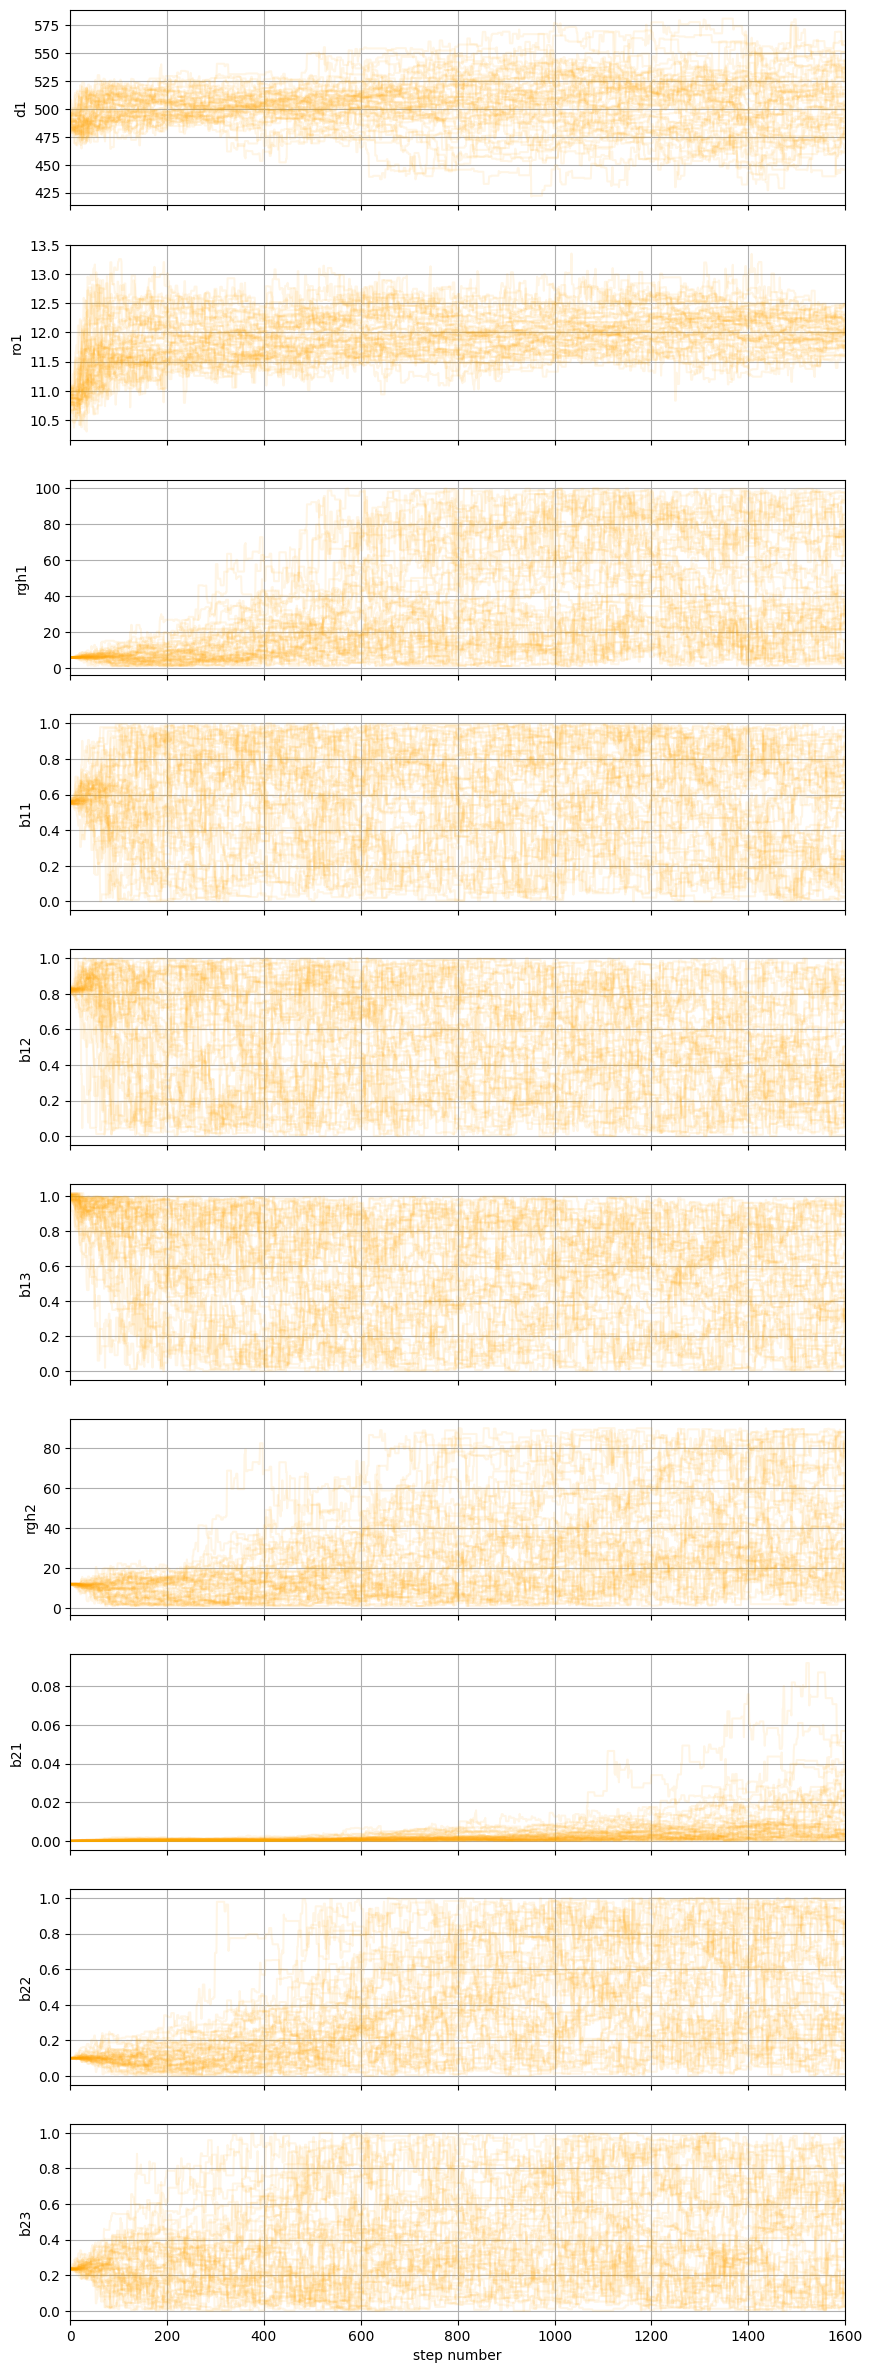

In [41]:
fig, axes = plt.subplots(10, figsize=(10, 30), sharex=True)
samples = sampler.get_chain()
labels = ["d1", "ro1", "rgh1", "b11", "b12","b13", "rgh2", "b21", "b22", "b23"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.1, color='orange')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.grid(True)

axes[-1].set_xlabel("step number");

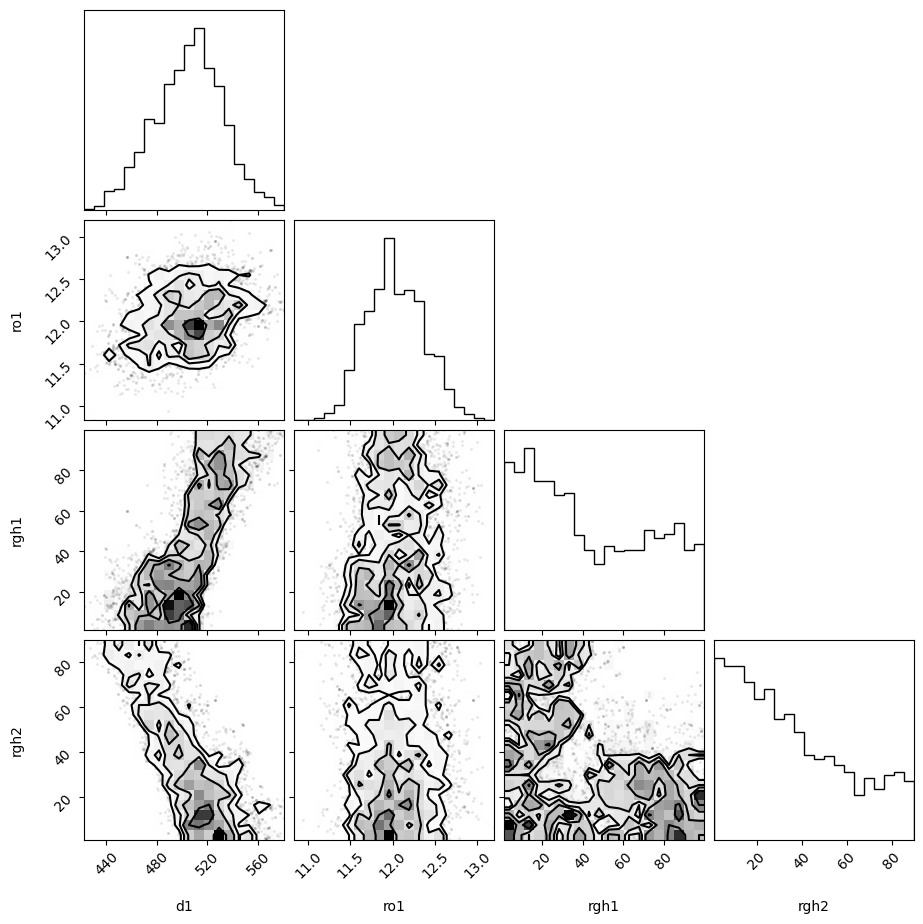

In [42]:
flat_samples = sampler.get_chain(discard=600, thin=10, flat=True)[:, [0,1,2,6]]
import corner

fig = corner.corner(
    flat_samples, labels=["d1", "ro1", "rgh1", "rgh2"]
)

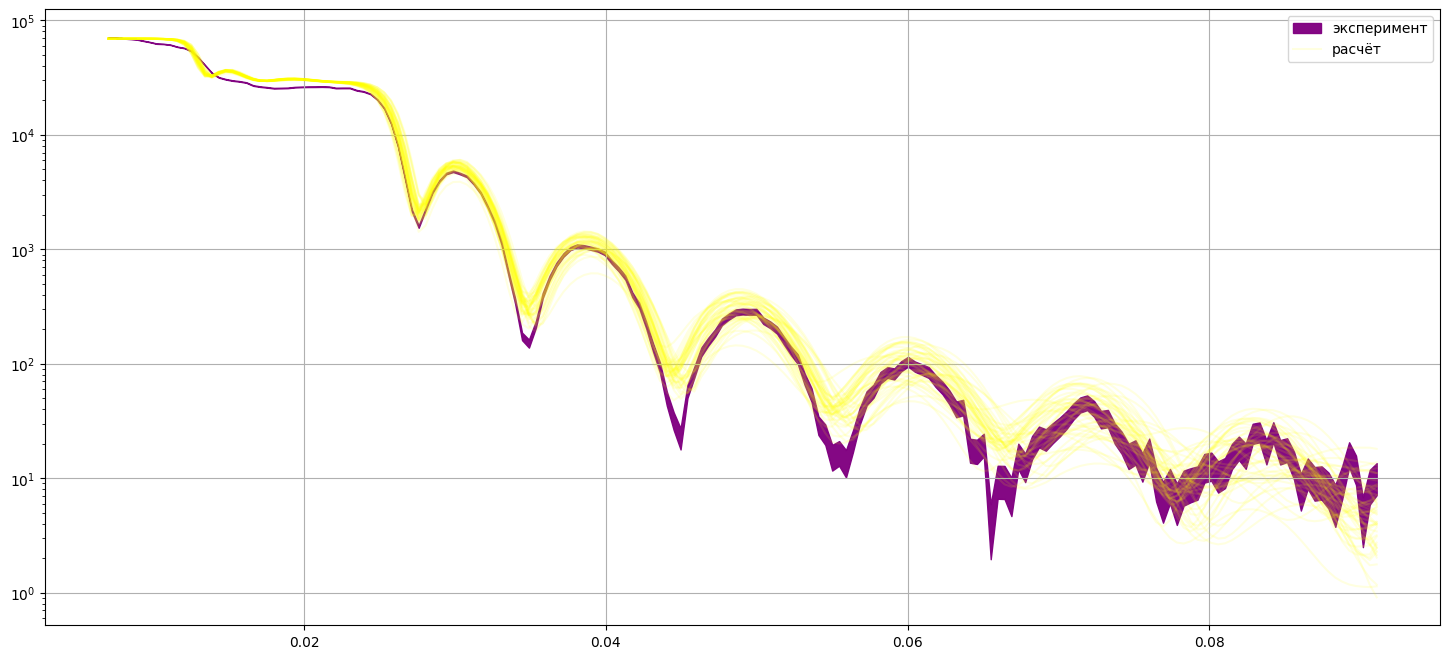

In [49]:
final_samples = samples[-1, :, :]
r_mod_list = []
matr_mod_list = []

for sample in final_samples:
    var_vector = torch.tensor(sample)

    new_matr = torch.cat((matr[0, :], var_vector[:6], torch.cat((matr[2, :2], var_vector[6:]), dim=0)), dim=0).reshape(-1, 6)

    _, r_mod_conv2, _ = reflectometry(q, new_matr, ans_sigma1, ans_sigma2, I0, Ibkg, ans_alpha2)
    r_mod_list.append(r_mod_conv2)
    matr_mod_list.append(transform_array(new_matr, rough_res))

fig, ax = plt.subplots(figsize=(18, 8))

# Заливка для экспериментальных данных
ax.fill_between(q*1e-10, r2, r1, color='purple', alpha=0.97, label='эксперимент')

# Отрисовка всех графиков из r_mod_list
for r_mod_conv2 in r_mod_list:
    ax.plot(q[0:len(r_mod_conv2.tolist())]*1e-10, (I0*r_mod_conv2).tolist(), color='yellow', alpha=0.12, label='расчёт' if r_mod_conv2 is r_mod_list[0] else None)

# Настройки осей и легенды
ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [51]:
def plot_density_profile_variator(matr_list):
    fig = go.Figure()

    # Проходим по каждому тензору в списке
    for matr in matr_list:
        matrix = torch.tensor(matr)
        depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
        U = (1.e-0) * matrix[:, 1].real

        x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
        y_fill = torch.repeat_interleave(U, 2)

        # Добавляем график с полупрозрачностью и одинаковым цветом
        fig.add_trace(go.Scatter(
            x=x_fill.detach().cpu().numpy(),
            y=y_fill.detach().cpu().numpy(),
            mode="lines",
            line=dict(color="darkgreen"),
            opacity=0.33,  # Полупрозрачность
            showlegend=(matr is matr_list[0])  # Показываем легенду только для первого графика
        ))

    # Настройки осей и макета
    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

fig = plot_density_profile_variator(matr_mod_list)
fig.show()